# Experiment 09 — Task 5: Gradient Boosting + Feature Selection

Task 3 established Gradient Boosting (depth=6, lr=0.05) as the best model with test AUC 0.6370.
This notebook adds two modifications:

1. **Improved featurizer** — `"improved"` instead of `"full"`: proper admission source grouping, collapsed rare race categories
2. **Feature selection** — top-30 features by mean permutation importance from exp_07

Same 5-fold CV + 15% held-out test setup as Task 3. Results go into the final comparison table.

In [ ]:
import sys, os
if 'google.colab' in str(get_ipython()):
    REPO = 'diabetes-uci-dataset'
    REPO_URL = 'https://github.com/byambaa0325/diabetes-uci-dataset.git'
    if not os.path.exists(REPO):
        os.system(f'git clone ${REPO_URL}')
    os.chdir(REPO)
    os.system('pip install -q -r requirements.txt')
else:
    root = os.path.abspath(os.path.join(os.getcwd(), '../../'))
    if root not in sys.path:
        sys.path.insert(0, root)

In [5]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.pipeline import cross_validate, run_pipeline

sns.set_theme(style='whitegrid')

TEST_RATIO  = 0.15
CV_SPLITS   = 5
RANDOM_SEED = 42

CV_CHECKPOINT_DIR = Path('../../outputs/checkpoints/task5_gb_fs_cv')
TEST_CHECKPOINT   = Path('../../outputs/checkpoints/task5_gb_fs_test.json')
CV_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

Setup complete.


---
## Feature selection from exp_07

Load permutation importance rankings and take the top N.
If exp_07 hasn't been run yet, falls back to a clinically motivated list.

In [6]:
PERM_PATH = Path('../../outputs/tables/permutation_importance.csv')
TOP_N     = 30

if PERM_PATH.exists():
    perm_df           = pd.read_csv(PERM_PATH, index_col=0)
    mean_imp          = perm_df.mean(axis=1).sort_values(ascending=False)
    selected_features = mean_imp.head(TOP_N).index.tolist()
    print(f'Loaded permutation importance — top {TOP_N} features selected')
else:
    print('permutation_importance.csv not found — using clinical fallback list')
    print('Run exp_07 first for a data-driven selection')
    selected_features = [
        'number_inpatient', 'prior_hospital_load', 'number_emergency', 'number_outpatient',
        'num_diagnoses', 'num_medications', 'total_meds_prescribed', 'time_in_hospital',
        'num_lab_procedures', 'num_procedures', 'lab_to_procedure_ratio',
        'age', 'age_x_medications',
        'a1cresult', 'a1c_poor_control', 'max_glu_serum', 'insulin', 'insulin_adjusted',
        'discharge_group_home', 'discharge_group_transfer', 'discharge_group_expired',
        'admission_group_emergency', 'admission_group_other',
        'admission_source_group_emergency', 'admission_source_group_transfer',
        'change', 'diabetesmed',
        'diag_1_group_Circulatory', 'diag_1_group_Diabetes', 'diag_1_group_Respiratory',
    ]

print(f'\n{len(selected_features)} features selected:')
print(selected_features)

permutation_importance.csv not found — using clinical fallback list
Run exp_07 first for a data-driven selection

30 features selected:
['number_inpatient', 'prior_hospital_load', 'number_emergency', 'number_outpatient', 'num_diagnoses', 'num_medications', 'total_meds_prescribed', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'lab_to_procedure_ratio', 'age', 'age_x_medications', 'a1cresult', 'a1c_poor_control', 'max_glu_serum', 'insulin', 'insulin_adjusted', 'discharge_group_home', 'discharge_group_transfer', 'discharge_group_expired', 'admission_group_emergency', 'admission_group_other', 'admission_source_group_emergency', 'admission_source_group_transfer', 'change', 'diabetesmed', 'diag_1_group_Circulatory', 'diag_1_group_Diabetes', 'diag_1_group_Respiratory']


---
## Config

Best GB config from exp_05: depth=6, lr=0.05, n_estimators=200, subsample=0.8.
Switching featurizer to `"improved"` and applying top-30 feature selection.

In [7]:
BASE_CONFIG = {
    'name':              'task5_gb_fs',
    'model':             'gradient_boosting',
    'wandb_project':     'applied-ai-coursework',
    'featurizer':        'improved',
    'selected_features':  selected_features,
    'test_ratio':         TEST_RATIO,
    'model_params': {
        'n_estimators':  200,
        'max_depth':     6,
        'learning_rate': 0.05,
        'subsample':     0.8,
        'random_state':  RANDOM_SEED,
    },
}

print('Model          :', BASE_CONFIG['model'])
print('Featurizer     :', BASE_CONFIG['featurizer'])
print('Features       :', len(selected_features))
print('Model params   :', BASE_CONFIG['model_params'])

Model          : gradient_boosting
Featurizer     : improved
Features       : 30
Model params   : {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'random_state': 42}


---
## 5-fold CV — resumable

In [10]:
summary_path = CV_CHECKPOINT_DIR / 'summary.json'

if summary_path.exists():
    print('CV already complete — loading from checkpoint.')
    cv_result = json.loads(summary_path.read_text())
else:
    completed = sorted(CV_CHECKPOINT_DIR.glob('fold_*.json'))
    if completed:
        print(f'Resuming CV — {len(completed)}/{CV_SPLITS} folds already done.')
    else:
        print(f'Starting {CV_SPLITS}-fold CV...')

    cv_result = cross_validate(
        BASE_CONFIG,
        n_splits=CV_SPLITS,
        random_state=RANDOM_SEED,
        checkpoint_dir=CV_CHECKPOINT_DIR,
    )
    summary_path.write_text(json.dumps(cv_result['summary'], indent=2))
    print('CV complete.')

s = cv_result['summary']
print(f"\nCV Results ({CV_SPLITS} folds):")
print(f"  ROC-AUC    : {s['roc_auc_mean']:.4f} ± {s['roc_auc_std']:.4f}")
print(f"  F1         : {s['f1_mean']:.4f} ± {s['f1_std']:.4f}")
print(f"  Recall(pos): {s['recall_pos_mean']:.4f} ± {s['recall_pos_std']:.4f}")
print(f"  Precision  : {s['precision_mean']:.4f} ± {s['precision_std']:.4f}")

Starting 5-fold CV...
  fold 1/5  

train_log_loss,▁
val_log_loss,▁
train_log_loss,0.60304
val_log_loss,0.6468


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-10_03-53-50_a758b2_task5_gb_fs
  [saved]
  fold 2/5  

train_log_loss,▁
val_log_loss,▁
train_log_loss,0.60367
val_log_loss,0.64507


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-10_03-54-13_608609_task5_gb_fs
  [saved]
  fold 3/5  

...

Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-10_03-54-36_069d14_task5_gb_fs
  [saved]
  fold 4/5  

train_log_loss,▁
val_log_loss,▁
train_log_loss,0.60241
val_log_loss,0.64971


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-10_03-54-58_4462a6_task5_gb_fs
  [saved]
  fold 5/5  

train_log_loss,▁
val_log_loss,▁
train_log_loss,0.6018
val_log_loss,0.64849


Run saved: E:\UCL-Workspaces\applied-ai-coursework\runs\2026-03-10_03-55-20_b16f3c_task5_gb_fs
  [saved]
CV complete.

CV Results (5 folds):
  ROC-AUC    : 0.6544 ± 0.0064
  F1         : 0.6218 ± 0.0017
  Recall(pos): 0.8885 ± 0.0262
  Precision  : 0.4787 ± 0.0092


---
## Test set evaluation

First and only time the 15% held-out test set is used.

In [12]:
import wandb

if TEST_CHECKPOINT.exists():
    print('Test result already exists — loading from checkpoint.')
    tm = json.loads(TEST_CHECKPOINT.read_text())
else:
    print('Running test set evaluation...')
    result = run_pipeline({**BASE_CONFIG, 'split_ratio': 0.88, 'plot': True})
    wandb.finish()   # close wandb run opened by stage_train to unblock the cell
    tm = result.test_metrics
    TEST_CHECKPOINT.write_text(json.dumps(
        {k: float(v) if isinstance(v, (int, float)) else v
         for k, v in tm.items()
         if not hasattr(v, '__len__') or isinstance(v, (str, list))},
        indent=2
    ))
    print('Saved.')

print(f"\nTest set:")
print(f"  ROC-AUC    : {tm['roc_auc']:.4f}")
print(f"  F1         : {tm['f1']:.4f}")
print(f"  Recall(pos): {tm['recall_pos']:.4f}")
print(f"  Threshold  : {tm['threshold']:.3f}")

Test result already exists — loading from checkpoint.

Test set:
  ROC-AUC    : 0.6250
  F1         : 0.4523
  Recall(pos): 0.7301
  Threshold  : 0.424


---
## Comparison against Task 3 baseline and Task 5 TabICL

In [11]:
table_path = Path('../../outputs/tables/final_model_comparison.csv')
s = cv_result['summary']

gb_fs_row = pd.DataFrame([{
    'model':            'gb_improved_fs',
    'best_config':      f'GB depth=6 lr=0.05 (improved, top-{len(selected_features)} features)',
    'CV ROC-AUC':       f"{s['roc_auc_mean']:.4f} ± {s['roc_auc_std']:.4f}",
    'CV F1':            f"{s['f1_mean']:.4f} ± {s['f1_std']:.4f}",
    'CV Recall(pos)':   f"{s['recall_pos_mean']:.4f} ± {s['recall_pos_std']:.4f}",
    'Test ROC-AUC':     round(tm['roc_auc'], 4),
    'Test F1':          round(tm['f1'], 4),
    'Test Recall(pos)': round(tm['recall_pos'], 4),
    'Test Threshold':   round(tm['threshold'], 3),
}]).set_index('model')

if table_path.exists():
    existing = pd.read_csv(table_path, index_col='model')
    existing = existing[existing.index != 'gb_improved_fs']
    combined = pd.concat([existing, gb_fs_row])
else:
    combined = gb_fs_row

combined.to_csv(table_path)
display(combined)

,best_config,CV ROC-AUC,CV F1,CV Recall(<30),Test ROC-AUC,Test F1,Test Recall(<30),Test Threshold,Time(s),CV Recall(pos),Test Recall(pos)
model,,,,,,,,,,,
linear_svm,lsvm_C0.01,0.6486 ± 0.0043,0.6134 ± 0.0017,0.9172 ± 0.0136,0.6276,0.4475,0.7709,0.498,5.7,NaN,NaN
logistic_regression,lr_C0.1,0.6495 ± 0.0045,0.6133 ± 0.0017,0.9040 ± 0.0248,0.6277,0.4469,0.8450,0.466,15.2,NaN,NaN
random_forest,rf_depth12,0.6723 ± 0.0056,0.6231 ± 0.0026,0.8810 ± 0.0328,0.6342,0.4506,0.8246,0.478,6.5,NaN,NaN
gradient_boosting,gb_depth6_lr0.05,0.6776 ± 0.0048,0.6257 ± 0.0026,0.8799 ± 0.0266,0.6370,0.4503,0.8288,0.409,59.5,NaN,NaN
tabicl,tabicl (subsample=10000),0.6662 ± 0.0042,0.6210 ± 0.0018,0.8933 ± 0.0226,0.6304,0.4470,0.8157,0.421,55.2,NaN,NaN
gb_improved_fs,"GB depth=6 lr=0.05 (improved, top-30 features)",0.6544 ± 0.0064,0.6218 ± 0.0017,NaN,0.6250,0.4523,NaN,0.424,NaN,0.8885 ± 0.0262,0.7301


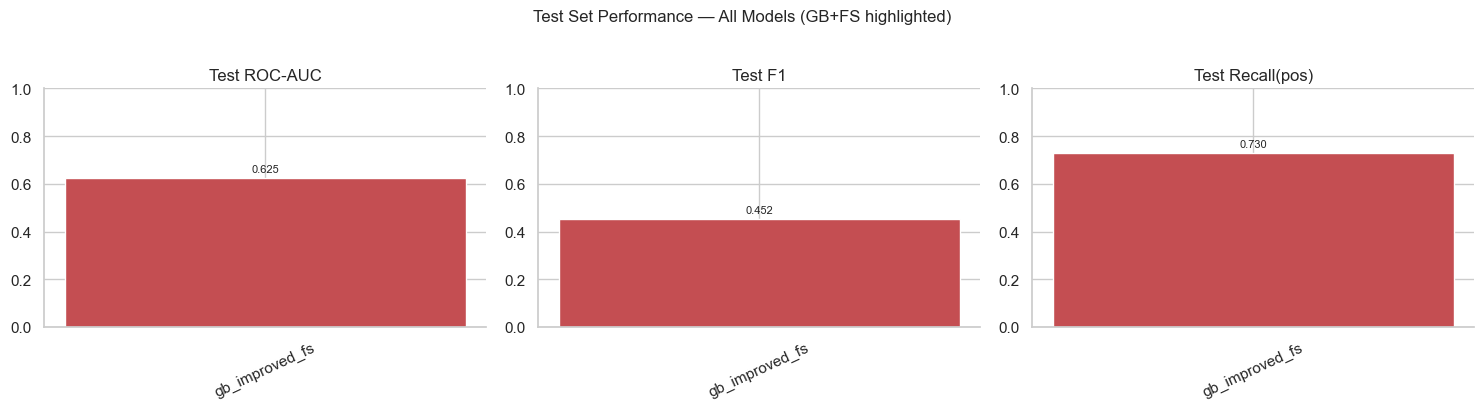

In [13]:
numeric_cols = ['Test ROC-AUC', 'Test F1', 'Test Recall(pos)']
rename_map   = {'Test Recall(<30)': 'Test Recall(pos)', 'CV Recall(<30)': 'CV Recall(pos)'}
plot_df = combined[numeric_cols].rename(columns=rename_map).dropna()

colors = ['#C44E52' if 'gb_improved_fs' in idx else '#4C72B0' for idx in plot_df.index]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    bars = ax.bar(plot_df.index, plot_df[col], color=colors, edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
    ax.set_title(col)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=25)
    sns.despine(ax=ax)

fig.suptitle('Test Set Performance — All Models (GB+FS highlighted)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../../outputs/figures/all_models_comparison.png', bbox_inches='tight', dpi=120)
plt.show()